[2026-08-05 14:35:14] [info     ] 合规检查                           duplicate_keys=0 factor_std=0.5704052928016475 has_inf=False maximum_coverage=1000 minimum_coverage=1000 rows=242000 trading_days=242 zero_rate=0.0034917355371900825
[2026-08-05 14:35:14] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-08-05 14:35:16] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-08-05 14:35:18] [warning  ] 未传入官方评估窗口 start_date/end_date，回退到数据自身范围（仅建议本地调试时使用）
[2026-08-05 14:35:19] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2024-01-02 至 2024-12-31
[2026-08-05 14:35:19] [info     ] ========== 数据检查 ==========
[2026-08-05 14:35:19] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor', 'close', 'volume', 'amount', 'turn', 'change_ratio', 'daily_return', 'momentum_5', 'reversal_5', 'volatility_5', 'total_market_cap', 'float_market_cap', 'pe_ttm', 'pb', 'ps_ttm', 'sma_20', 'ema_20', 'macd_diff_12_26_9', 'macd_dea_12_26_9', 'macd_hist_12_26_9', 'rsi_12', 'kdj_k_

时段,IC
2024-01-15~2024-02-08,0.0357
2024-09-24~2024-10-08,0.0517

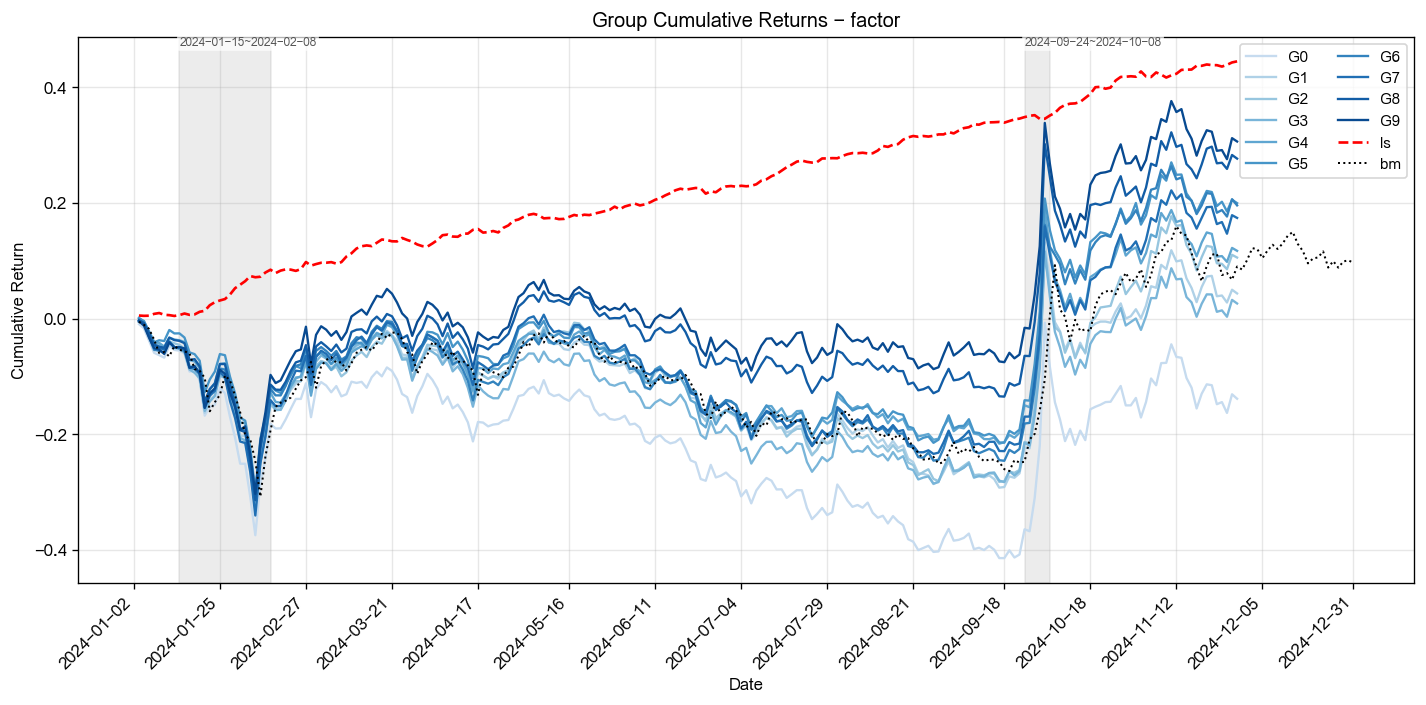
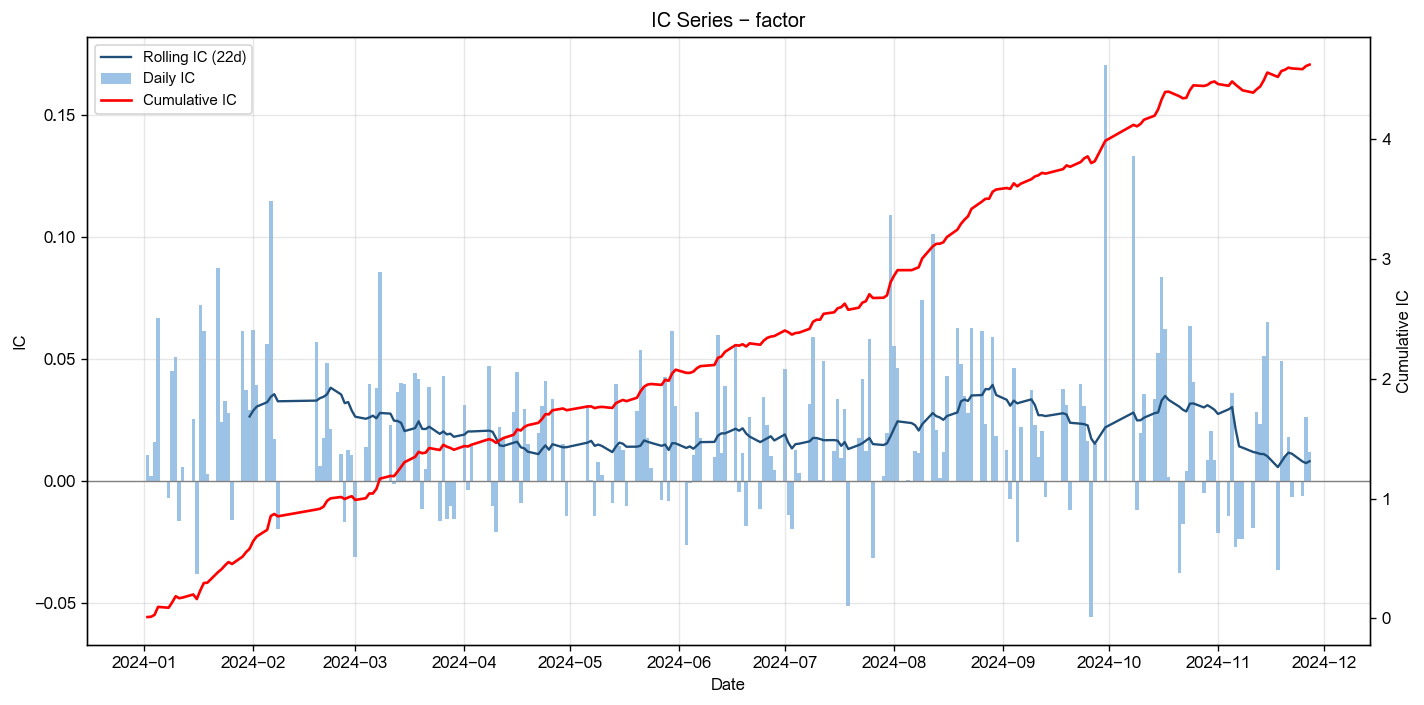
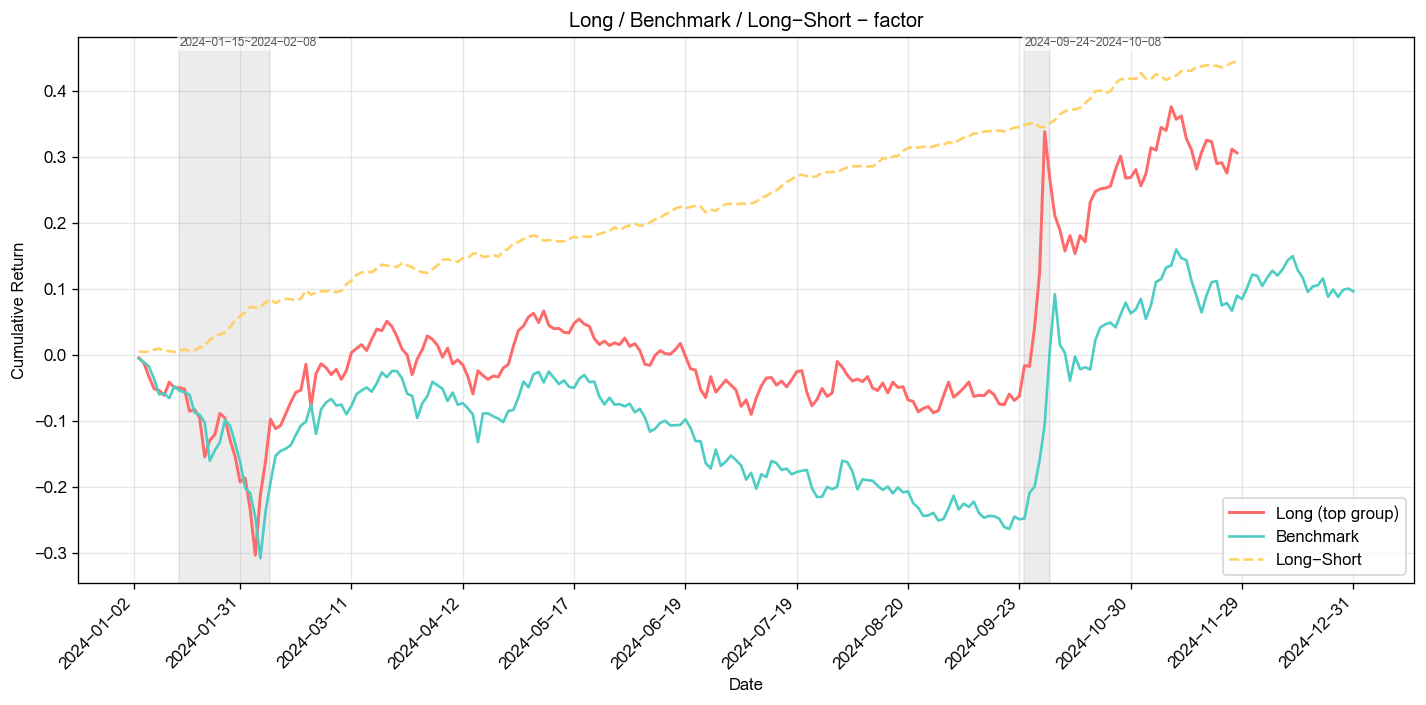
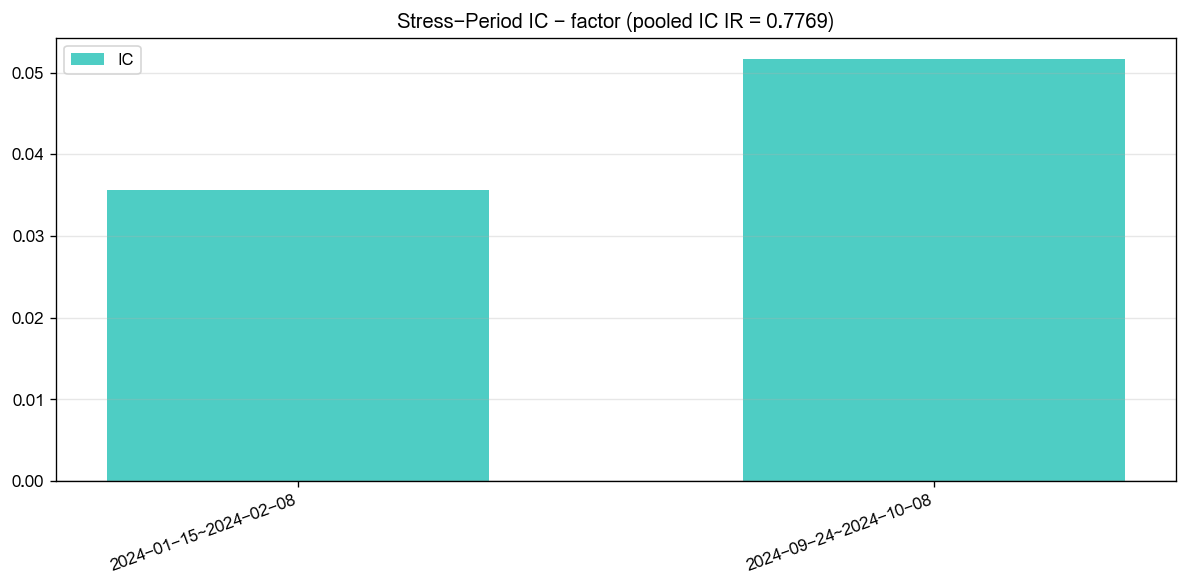
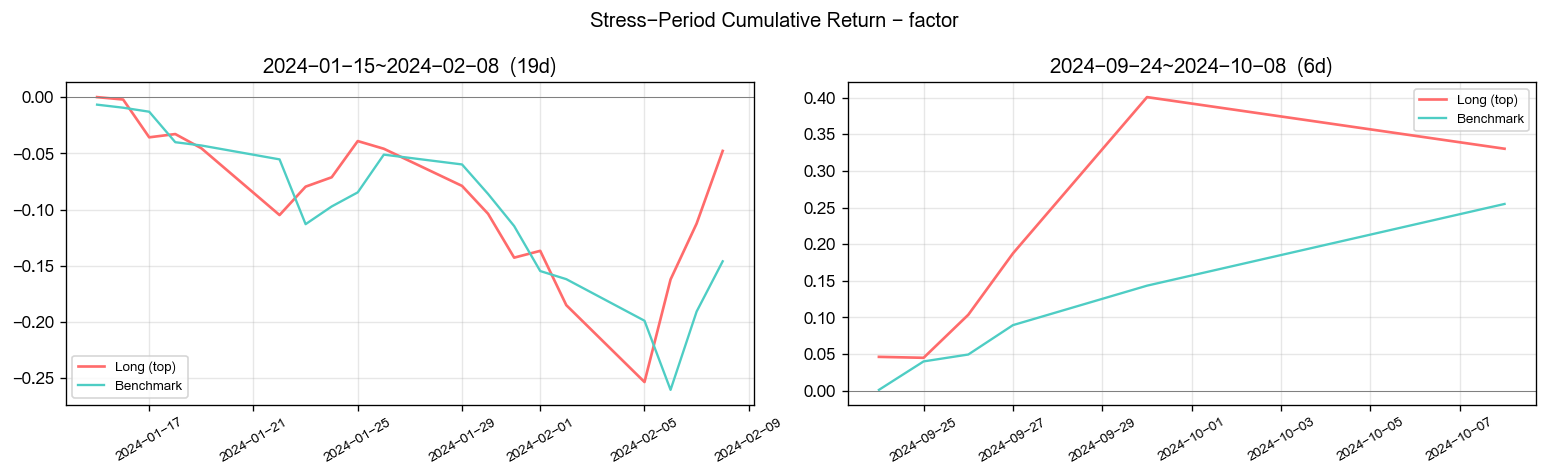

[2026-08-05 14:35:38] [info     ] ========== 因子池回归 ==========
[2026-08-05 14:35:39] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1206 rows=297953 start_date=2024-01-02
[2026-08-05 14:35:39] [info     ] 获取收益率数据, 耗时: 0.4699 秒
[2026-08-05 14:35:39] [info     ] 滚动 Elastic Net 拟合, 耗时: 0.5318 秒
[2026-08-05 14:35:39] [info     ] 统计 回归结果, 耗时: 0.0062 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,factor,3.9392,0.0333,0.0085,1.0000
2,rsi_12,1.9729,0.0447,0.0226,1.0000
3,amount,1.6738,0.0177,0.0106,0.9000
4,netflow_amount_rate_main,1.6086,0.0098,0.0061,1.0000
5,gross_profit_rate_ttm,1.5047,0.0068,0.0045,1.0000
6,netflow_amount_main,1.4980,0.0253,0.0169,1.0000
7,net_profit_rate_ttm,1.4833,0.0040,0.0027,0.8000
8,pb,1.4426,0.0097,0.0068,0.9000
9,cci_14,1.4190,0.0339,0.0239,1.0000
10,bias_20,1.4179,0.0293,0.0206,0.9000

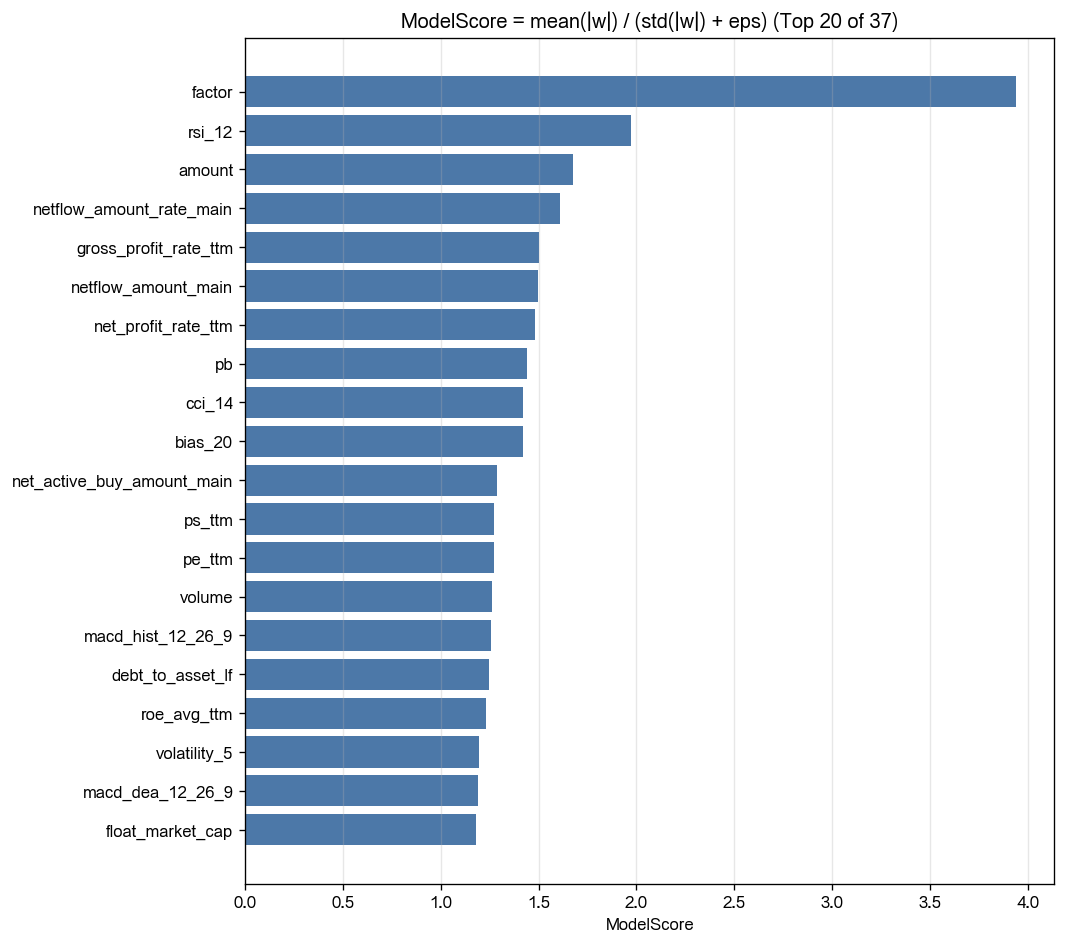
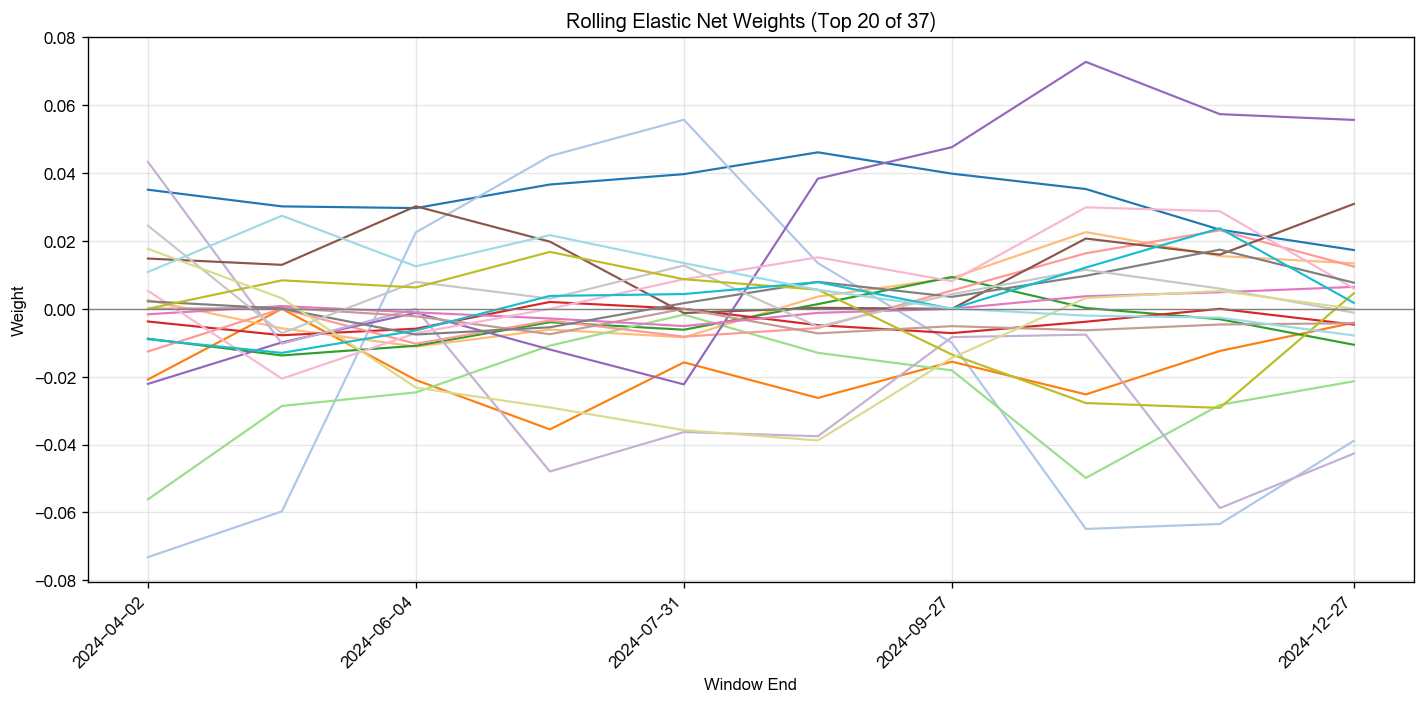
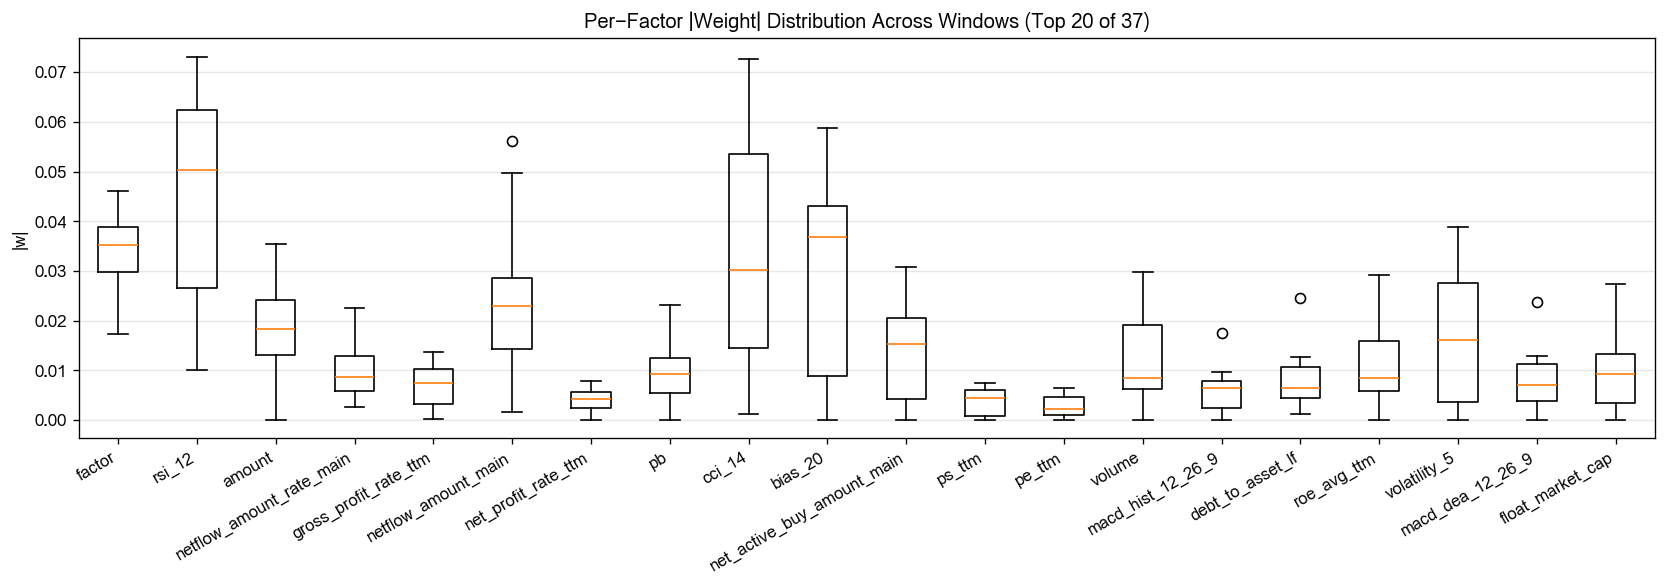
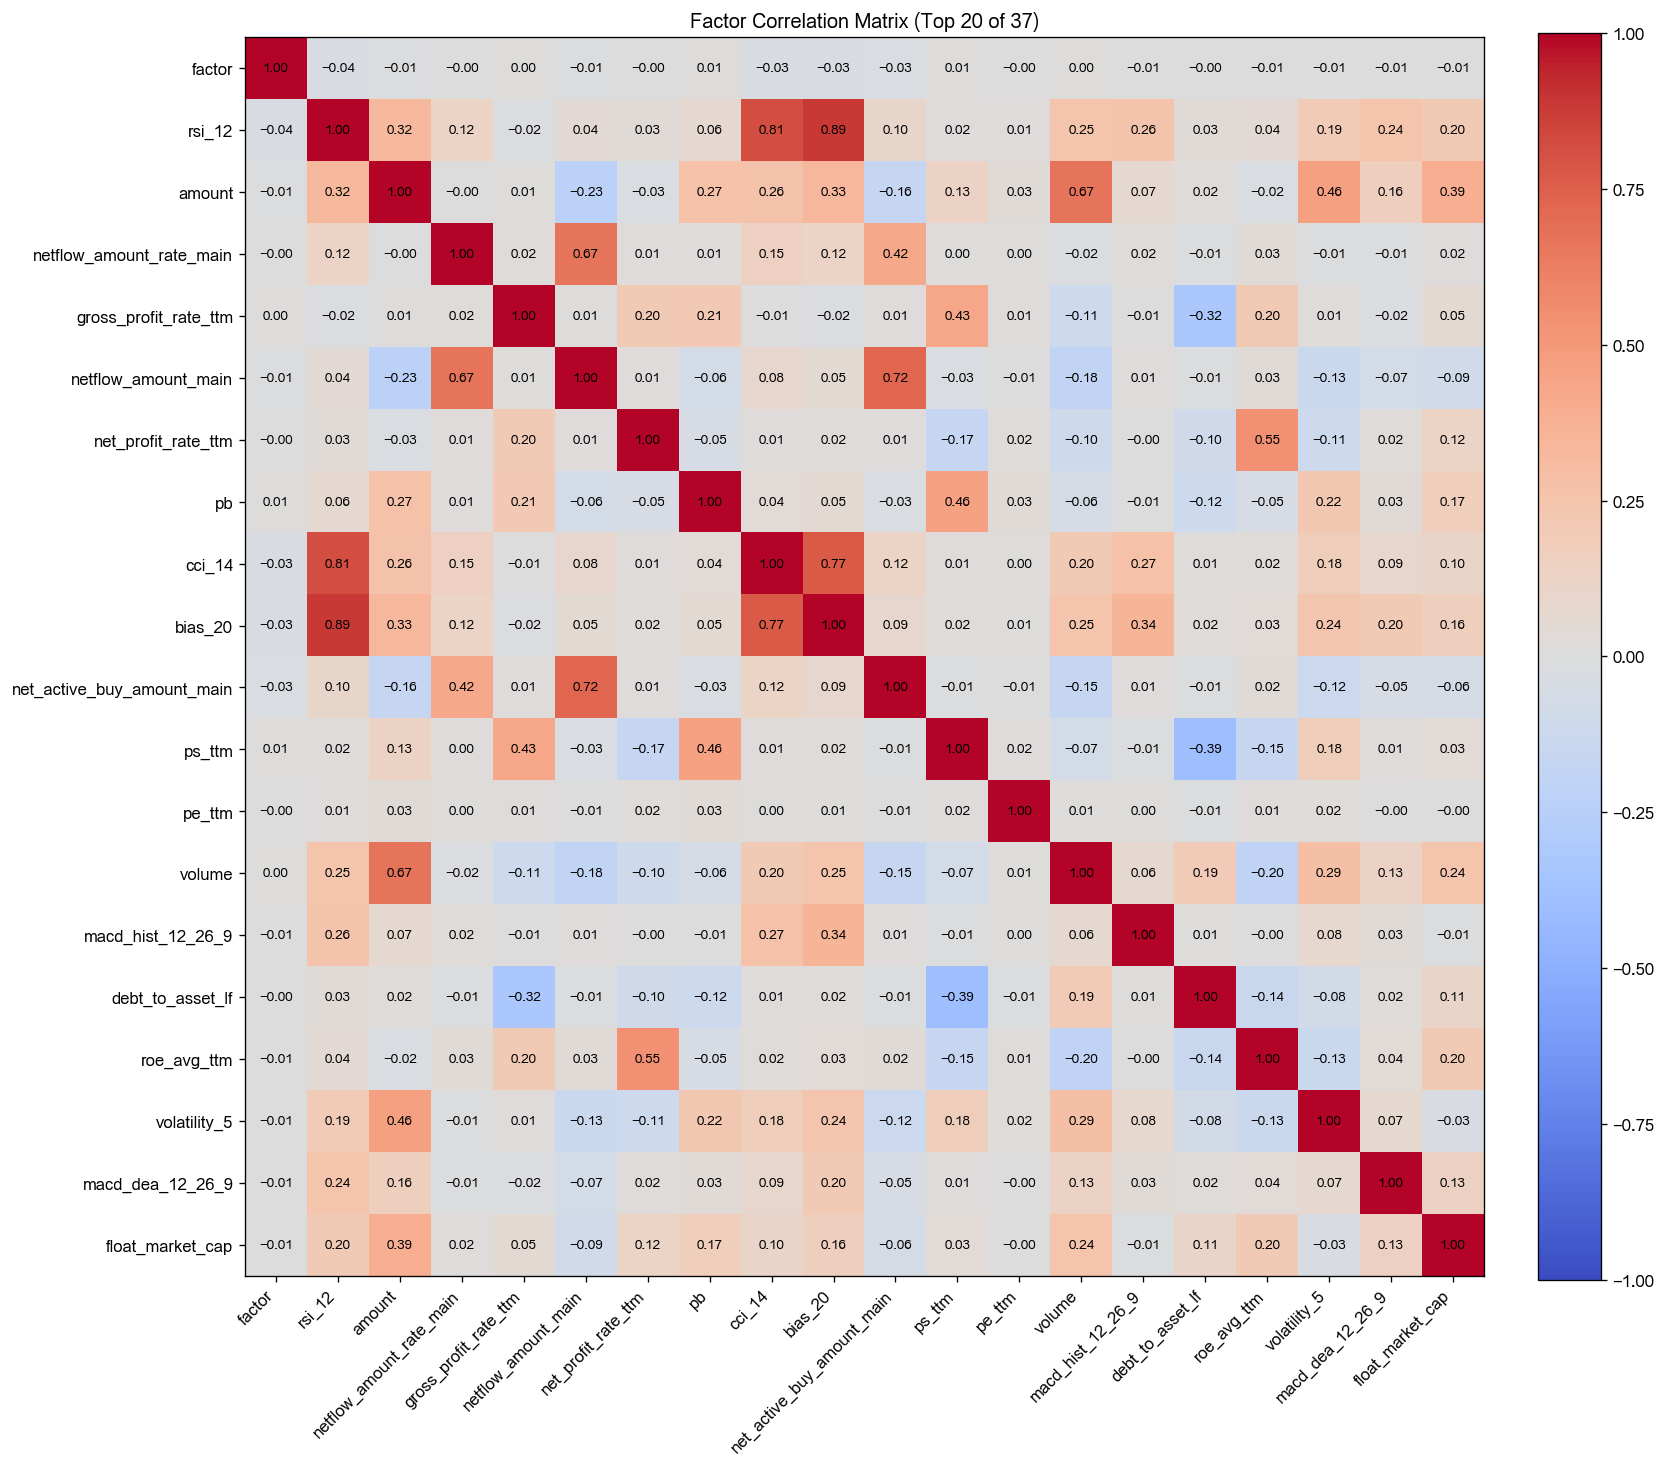

[2026-08-05 14:35:41] [warning  ] 返回的Outputs实例(size=34616917) 大于 64K, 将不会被缓存
[2026-08-05 14:35:41] [info     ] bigalpha_eval.v4 运行完成 [24.928s].


In [1]:
"""
CAPR：收盘集合竞价价格压力反转因子
Closing Auction Price-pressure Reversal

因子比较 14:56 连续竞价末端价格与 15:00 收盘价格。若集合竞价阶段把收盘价
相对推高，预测次日均值回归、因子取负；若相对压低，因子取正。
价格位移使用连续竞价尾段分钟波动率和相对价差缩放，再做每日截面排名。
"""


AI_APPLICATION_NOTES = r"""
赛道：AI 智能赛道。

OpenAI Codex 参与评分结构分析、候选信息源去重、微观结构假设生成、公式设计、
DAI SQL 实现、覆盖度修复和结果诊断。人工负责平台运行、指标核验和提交决策。

研究假设：收盘集合竞价包含指数跟踪、被动调仓及集中执行订单，可能把15:00
收盘价短暂推离14:56连续竞价末端价格。该临时价格压力在下一交易日均值回归。
因子不使用未来数据，所有输入均在当日15:00后可获得。

2024本地诊断：IC Mean 0.021202，IC_IR 0.671145，多空夏普 8.079699，
Stress IC_IR 0.776879。原始日频版本全面优于3日平滑版本，因此不做平滑。
输出以官方中证1000股票池为母表，对无有效集合竞价记录的股票填中性值0，
保证单日增量评测覆盖合规。
"""


def main(datasources, start_date, end_date):
    import numpy as np
    import pandas as pd
    import dai

    bar1m = datasources["bar1m"]

    sql = f"""
    WITH afternoon_minutes AS (
        SELECT
            date,
            instrument,
            strftime(date, '%Y-%m-%d') AS trading_day,
            strftime(date, '%H%M') AS hhmm,
            close,
            CASE
                WHEN ask_price1 > 0 AND bid_price1 > 0
                THEN (ask_price1 - bid_price1)
                     / ((ask_price1 + bid_price1) / 2.0 + 1e-8)
                ELSE NULL
            END AS relative_spread,
            LAG(close, 1) OVER (
                PARTITION BY instrument, strftime(date, '%Y-%m-%d')
                ORDER BY date
            ) AS previous_close
        FROM {bar1m}
        WHERE strftime(date, '%H%M') >= '1430'
          AND strftime(date, '%H%M') <= '1500'
          AND close > 0
    ),
    continuous_window AS (
        SELECT
            trading_day,
            instrument,
            ARG_MAX(close, date) AS continuous_close,
            AVG(relative_spread) AS continuous_spread,
            NANSTD(
                CASE
                    WHEN close > 0 AND previous_close > 0
                    THEN LOG(close / previous_close)
                    ELSE NULL
                END
            ) AS continuous_volatility
        FROM afternoon_minutes
        WHERE hhmm >= '1430' AND hhmm <= '1456'
        GROUP BY trading_day, instrument
        HAVING COUNT(*) >= 10
    ),
    auction_window AS (
        SELECT
            trading_day,
            instrument,
            ARG_MAX(close, date) AS auction_close
        FROM afternoon_minutes
        WHERE hhmm >= '1457' AND hhmm <= '1500'
        GROUP BY trading_day, instrument
        HAVING COUNT(*) >= 1
    ),
    daily_raw AS (
        SELECT
            CAST(c.trading_day AS DATETIME) AS date,
            c.instrument,
            LOG(a.auction_close / c.continuous_close)
                / (
                    COALESCE(c.continuous_volatility, 0) +
                    COALESCE(c.continuous_spread, 0) +
                    1e-6
                ) AS normalized_auction_move
        FROM continuous_window c
        INNER JOIN auction_window a
            ON c.trading_day = a.trading_day
           AND c.instrument = a.instrument
        WHERE c.continuous_close > 0
          AND a.auction_close > 0
    ),
    daily_in_pool AS (
        SELECT d.*
        FROM daily_raw d
        INNER JOIN bigalpha_2026_instruments u
            ON d.date = u.date
           AND d.instrument = u.instrument
    ),
    ranked_signal AS (
        SELECT
            date,
            instrument,
            -(2.0 * PERCENT_RANK() OVER (
                PARTITION BY date ORDER BY normalized_auction_move
            ) - 1.0) AS factor
        FROM daily_in_pool
        WHERE normalized_auction_move IS NOT NULL
    )
    SELECT date, instrument, factor
    FROM ranked_signal
    ORDER BY date, instrument
    """

    df = dai.query(
        sql,
        filters={"date": [start_date, end_date]},
        compression=True,
    ).df()

    stock_pool = dai.query(
        "SELECT date, instrument FROM bigalpha_2026_instruments",
        filters={"date": [start_date, end_date]},
    ).df()
    df["date"] = pd.to_datetime(df["date"])
    stock_pool["date"] = pd.to_datetime(stock_pool["date"])
    df["instrument"] = df["instrument"].astype(str)
    stock_pool["instrument"] = stock_pool["instrument"].astype(str)

    result = pd.merge(
        stock_pool,
        df[["date", "instrument", "factor"]],
        how="left",
        on=["date", "instrument"],
    )
    result["factor"] = pd.to_numeric(result["factor"], errors="coerce")
    result["factor"] = result["factor"].replace([np.inf, -np.inf], np.nan)
    result["factor"] = result["factor"].fillna(0.0)

    return (
        result[["date", "instrument", "factor"]]
        .sort_values(["date", "instrument"])
        .reset_index(drop=True)
    )


if __name__ == "__main__":
    import numpy as np
    import dai
    import structlog
    from bigmodule import M

    logger = structlog.get_logger()
    datasources = {"bar1m": "bigalpha_2026_stock_bar1m"}
    start_date = "2024-01-01 00:00:00"
    end_date = "2024-12-31 23:59:59"

    factor_data = main(datasources, start_date, end_date)
    coverage = factor_data.groupby("date")["instrument"].nunique()
    logger.info(
        "合规检查",
        rows=len(factor_data),
        trading_days=factor_data["date"].nunique(),
        minimum_coverage=int(coverage.min()),
        maximum_coverage=int(coverage.max()),
        duplicate_keys=int(factor_data.duplicated(["date", "instrument"]).sum()),
        has_inf=bool(np.isinf(factor_data["factor"]).any()),
        factor_std=float(factor_data["factor"].std()),
        zero_rate=float((factor_data["factor"].abs() < 1e-12).mean()),
    )

    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={"date": [start_date, end_date]},
    ).df()
    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=True,
    )
